# Modelling Volatility Surfaces for Option Prices

## Implementation of a Volatility Surface using Geometric Interpolation

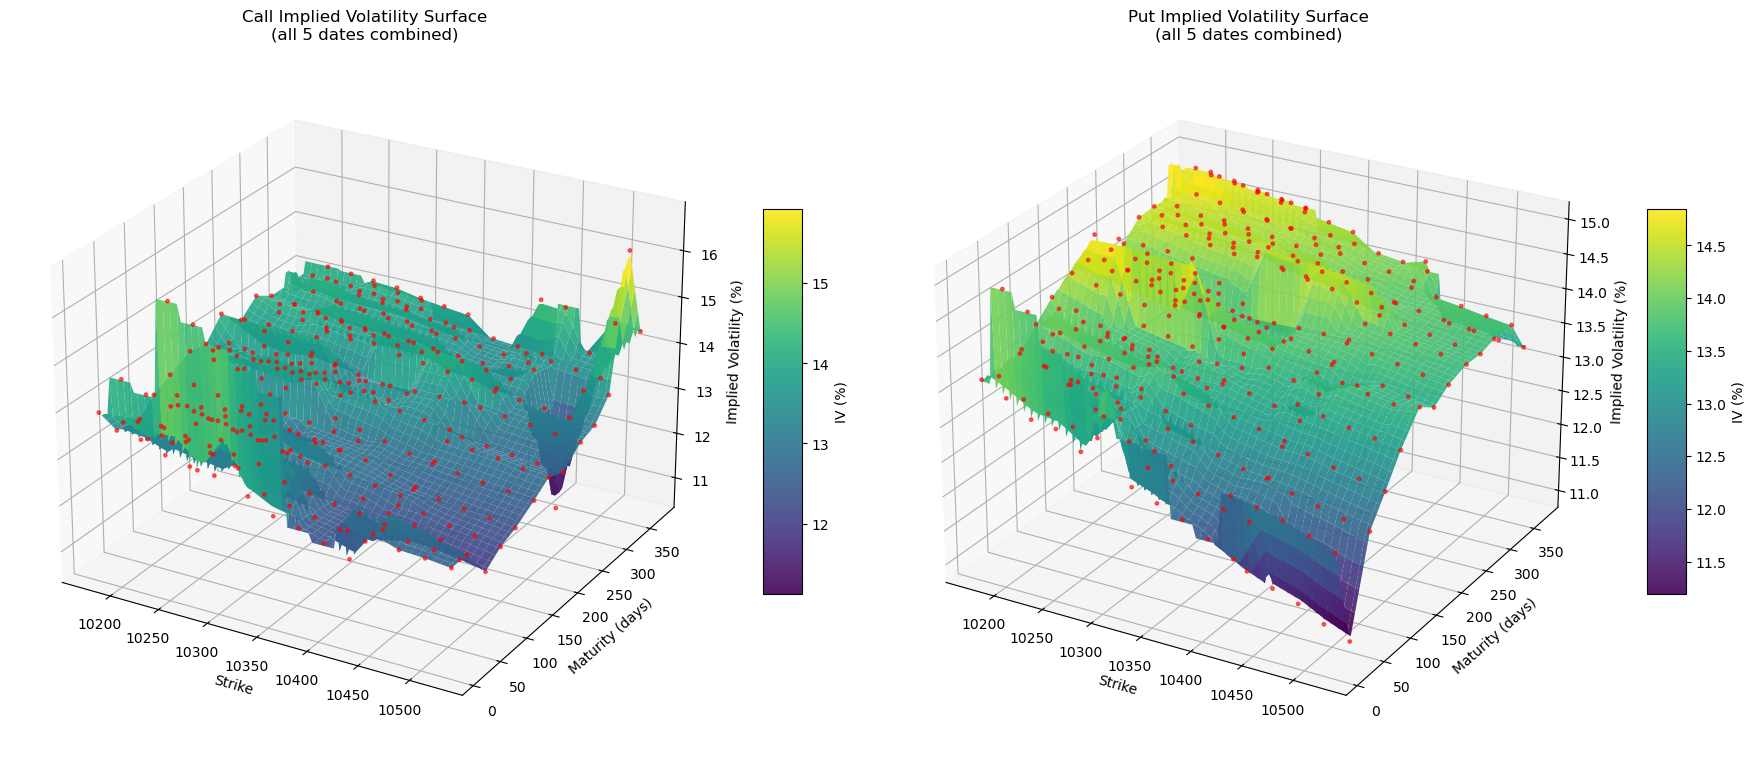

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata

df = pd.read_csv('clean_options.csv')

fig = plt.figure(figsize=(18, 8))

for idx, opt_type in enumerate(['Call', 'Put']):
    sub = df[df['Type'] == opt_type]
    strike = sub['Strike'].values
    maturity = sub['Maturity'].values
    iv = sub['ImpliedVol'].values

    strike_grid = np.linspace(strike.min(), strike.max(), 100)
    maturity_grid = np.linspace(maturity.min(), maturity.max(), 100)
    X, Y = np.meshgrid(strike_grid, maturity_grid)

    Z = griddata((strike, maturity), iv, (X, Y), method='linear')
    Z_nearest = griddata((strike, maturity), iv, (X, Y), method='nearest')
    Z = np.where(np.isnan(Z), Z_nearest, Z)

    ax = fig.add_subplot(1, 2, idx + 1, projection='3d')
    surf = ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none', alpha=0.9)
    ax.scatter(strike, maturity, iv, color='red', s=6, alpha=0.6)
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='IV (%)')
    ax.set_xlabel('Strike')
    ax.set_ylabel('Maturity (days)')
    ax.set_zlabel('Implied Volatility (%)')
    ax.set_title(f'{opt_type} Implied Volatility Surface\n(all 5 dates combined)')
    ax.view_init(elev=25, azim=-60)

plt.tight_layout()
plt.savefig("vol_surf.png")

## Leave one out testing all the points

In [4]:
import pandas as pd
import numpy as np
from scipy.interpolate import griddata

df = pd.read_csv('tidy_options.csv')

def loocv_all_points(data, opt_type):
    """
    Runs leave-one-out cross-validation across every point of the given
    option type: for each point, rebuild the surface without it and record
    how far off the prediction was. Returns a DataFrame of results.
    """
    sub = data[data['Type'] == opt_type].reset_index(drop=True)
    results = []

    for i in sub.index:
        held_out = sub.loc[i]
        train = sub.drop(index=i)

        pred = griddata(
            (train['Strike'].values, train['Maturity'].values),
            train['ImpliedVol'].values,
            (held_out['Strike'], held_out['Maturity']),
            method='linear'
        )
        if np.isnan(pred):
            pred = griddata(
                (train['Strike'].values, train['Maturity'].values),
                train['ImpliedVol'].values,
                (held_out['Strike'], held_out['Maturity']),
                method='nearest'
            )
        pred = float(pred)

        results.append({
            'Strike': held_out['Strike'],
            'Maturity': held_out['Maturity'],
            'Actual': held_out['ImpliedVol'],
            'Predicted': pred,
            'Error': pred - held_out['ImpliedVol']
        })

    results = pd.DataFrame(results)
    results['AbsError'] = results['Error'].abs()
    return results

for opt_type in ['Call', 'Put']:
    res = loocv_all_points(df, opt_type)
    rmse = np.sqrt((res['Error'] ** 2).mean())
    mae = res['AbsError'].mean()
    print(f"\n{opt_type} — LOOCV across {len(res)} points")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  MAE:  {mae:.4f}")
    print(f"  Worst 5 predictions:")
    print(res.sort_values('AbsError', ascending=False).head(5).to_string(index=False))


Call — LOOCV across 375 points
  RMSE: 0.5017
  MAE:  0.3008
  Worst 5 predictions:
 Strike  Maturity    Actual  Predicted     Error  AbsError
  10475       308 10.754936  13.588098  2.833162  2.833162
  10325        11 12.908485  15.416399  2.507914  2.507914
  10350        11 12.628941  15.045585  2.416644  2.416644
  10525       343 16.342356  13.999671 -2.342685  2.342685
  10250         8 16.615707  14.424156 -2.191551  2.191551

Put — LOOCV across 375 points
  RMSE: 0.3662
  MAE:  0.2092
  Worst 5 predictions:
 Strike  Maturity    Actual  Predicted     Error  AbsError
  10425       375 13.990518  12.282960 -1.707558  1.707558
  10200         9 14.960991  13.423443 -1.537548  1.537548
  10200        10 13.423443  14.925418  1.501975  1.501975
  10225        10 13.209211  14.694120  1.484909  1.484909
  10525        35 11.030149  12.419516  1.389367  1.389367


## SVI Parametrisation

In [7]:
"""
SVI calibration pipeline demonstrated on the uploaded UKX option chain
(sheet '8-June-2026' of options_data.xlsx).

Pipeline:
1. Parse each maturity block (calls + puts, strikes, bid/ask, IVM).
2. Estimate the forward F_T for each maturity via put-call parity regression:
       C_mid - P_mid  =  D*(F - K)   =>   regress (C-P) on K
       slope = -D,  intercept = D*F   =>   F = intercept / (-slope)
3. Build data points (T_i, k_i, w_i):
       k_i = ln(K_i / F_T)                      (log-moneyness)
       w_i = IV_mid_i^2 * T_i                    (total implied variance)
   Two variance quotes exist per strike (call IV, put IV) - we average them
   when both exist, matching the paper's use of a single w(k,t) per (K,T).
4. Calibrate the RAW SVI slice formula (paper eq. 3.1):
       w(k; a,b,rho,m,sigma) = a + b*{ rho*(k-m) + sqrt((k-m)^2 + sigma^2) }
   independently for every maturity slice, minimizing sum of squared errors
   between market w_i and model w_hat_i, subject to the paper's no-arbitrage
   parameter constraints (b>=0, |rho|<1, sigma>0, a+b*sigma*sqrt(1-rho^2)>=0).
"""
import openpyxl
import numpy as np
from scipy.optimize import minimize
import json

PATH = "options_data.xlsx"
SHEET = "8-June-2026"


def parse_sheet(path, sheet_name):
    wb = openpyxl.load_workbook(path, data_only=True)
    ws = wb[sheet_name]
    rows = list(ws.iter_rows(min_row=1, max_row=ws.max_row, values_only=True))

    # find block header rows: col0 is a string like '19-Jun-26 (7d); CSize 10'
    blocks = []
    header_idxs = []
    for i, row in enumerate(rows):
        if isinstance(row[0], str) and "CSize" in row[0]:
            header_idxs.append(i)
    header_idxs.append(len(rows))  # sentinel

    for h in range(len(header_idxs) - 1):
        start = header_idxs[h]
        end = header_idxs[h + 1]
        label = rows[start][0]
        days = int(label.split("(")[1].split("d")[0])
        T = days / 365.0

        strikes, call_iv, put_iv, call_mid, put_mid = [], [], [], [], []
        for r in rows[start + 1:end]:
            if r[0] is None or not isinstance(r[0], (int, float)):
                continue
            K = float(r[0])
            c_bid, c_ask, c_ivm = r[2], r[3], r[5]
            p_bid, p_ask, p_ivm = r[9], r[10], r[12]
            strikes.append(K)
            call_iv.append(c_ivm)
            put_iv.append(p_ivm)
            call_mid.append(None if c_bid is None or c_ask is None else (c_bid + c_ask) / 2)
            put_mid.append(None if p_bid is None or p_ask is None else (p_bid + p_ask) / 2)

        blocks.append(dict(T=T, days=days, K=np.array(strikes),
                            call_iv=np.array(call_iv, dtype=float),
                            put_iv=np.array(put_iv, dtype=float),
                            call_mid=np.array([np.nan if v is None else v for v in call_mid]),
                            put_mid=np.array([np.nan if v is None else v for v in put_mid])))
    return blocks


def estimate_forward(K, call_mid, put_mid, min_points=2):
    """Put-call parity regression: C - P = D*F - D*K -> fit line, recover F."""
    mask = ~np.isnan(call_mid) & ~np.isnan(put_mid)
    K_, diff = K[mask], (call_mid - put_mid)[mask]

    if len(K_) < min_points:
        # Not enough call+put pairs to fit a line -> don't silently divide by
        # zero, just report the failure explicitly.
        return np.nan, np.nan

    # linear regression diff = intercept + slope*K
    A = np.vstack([np.ones_like(K_), K_]).T
    coef, *_ = np.linalg.lstsq(A, diff, rcond=None)
    intercept, slope = coef

    if np.isclose(slope, 0.0):
        # Degenerate fit (flat line) -> can't recover F, report failure.
        return np.nan, np.nan

    D = -slope
    F = intercept / (-slope)
    return F, D


def build_points(block):
    F, D = estimate_forward(block["K"], block["call_mid"], block["put_mid"])
    T = block["T"]
    K = block["K"]
    civ, piv = block["call_iv"], block["put_iv"]
    # average call/put IV when both present, else whichever exists
    iv = np.nanmean(np.vstack([civ, piv]), axis=0)
    good = ~np.isnan(iv) & (K > 0)
    k = np.log(K[good] / F)
    w = (iv[good] / 100.0) ** 2 * T   # IVM given in percent, e.g. 12.78 -> 0.1278
    return F, D, k, w


def raw_svi(k, a, b, rho, m, sigma):
    return a + b * (rho * (k - m) + np.sqrt((k - m) ** 2 + sigma ** 2))


def vol_rmse(k, w, T, params):
    """
    RMSE measured on the implied-volatility scale (sigma = sqrt(w/T)),
    rather than on total variance w directly. This puts every maturity on
    a common, T-independent scale, since w = sigma^2 * T means a fixed
    error in w corresponds to very different vol errors depending on T.
    """
    w_hat = raw_svi(k, *params)
    sigma_market = np.sqrt(w / T)
    sigma_model = np.sqrt(np.clip(w_hat, 0, None) / T)
    return np.sqrt(np.mean((sigma_market - sigma_model) ** 2))


def sse(params, k, w):
    a, b, rho, m, sigma = params
    w_hat = raw_svi(k, a, b, rho, m, sigma)
    return np.sum((w - w_hat) ** 2)


def calibrate_slice(k, w):
    # initial guess
    a0 = max(w.min() * 0.5, 1e-6)
    b0 = 0.1
    rho0 = 0.0
    m0 = k[np.argmin(w)]
    sigma0 = 0.1

    x0 = [a0, b0, rho0, m0, sigma0]
    bounds = [(-1, 2), (1e-6, 5), (-0.999, 0.999), (-2, 2), (1e-4, 3)]

    cons = [{
        "type": "ineq",
        "fun": lambda x: x[0] + x[1] * x[4] * np.sqrt(max(1 - x[2] ** 2, 0)) - 1e-8
    }]

    res = minimize(sse, x0, args=(k, w), method="SLSQP",
                    bounds=bounds, constraints=cons,
                    options={"maxiter": 500, "ftol": 1e-12})
    return res


if __name__ == "__main__":
    blocks = parse_sheet(PATH, SHEET)
    results = []
    for block in blocks:
        F, D, k, w = build_points(block)
        T = block["T"]

        if np.isnan(F) or len(k) < 5:
            print(f"T={block['T']:.4f} ({block['days']:>3}d)  "
                  f"SKIPPED - not enough valid call+put quotes to estimate forward")
            results.append(dict(days=block["days"], T=block["T"], F=F, n=len(k),
                                 a=np.nan, b=np.nan, rho=np.nan, m=np.nan, sigma=np.nan,
                                 sse=np.nan, rmse=np.nan, rmse_vol=np.nan, success=False))
            continue

        res = calibrate_slice(k, w)
        a, b, rho, m, sigma = res.x
        rmse = np.sqrt(res.fun / len(k))
        rmse_vol = vol_rmse(k, w, T, res.x)
        results.append(dict(days=block["days"], T=block["T"], F=F, n=len(k),
                             a=a, b=b, rho=rho, m=m, sigma=sigma,
                             sse=res.fun, rmse=rmse, rmse_vol=rmse_vol, success=res.success))

    for r in results:
        print(f"T={r['T']:.4f} ({r['days']:>3}d)  F~{r['F']:.1f}  n={r['n']:>2}  "
              f"a={r['a']:.5f} b={r['b']:.5f} rho={r['rho']:+.3f} m={r['m']:+.3f} sigma={r['sigma']:.3f}  "
              f"RMSE(w)={r['rmse']:.6f}  RMSE(vol)={r['rmse_vol']:.6f}")


T=1.1041 (403d)  SKIPPED - not enough valid call+put quotes to estimate forward
T=1.2000 (438d)  SKIPPED - not enough valid call+put quotes to estimate forward
T=0.0301 ( 11d)  F~10383.1  n= 5  a=-0.00936 b=0.09903 rho=+0.000 m=+0.004 sigma=0.099  RMSE(w)=0.000006  RMSE(vol)=0.000806
T=0.1068 ( 39d)  F~10408.8  n= 5  a=-0.00817 b=0.09909 rho=+0.000 m=+0.001 sigma=0.099  RMSE(w)=0.000025  RMSE(vol)=0.000941
T=0.2027 ( 74d)  F~10388.6  n= 5  a=-0.00677 b=0.09984 rho=-0.001 m=+0.017 sigma=0.099  RMSE(w)=0.000001  RMSE(vol)=0.000019
T=0.2795 (102d)  F~10415.1  n= 5  a=-0.00539 b=0.10009 rho=-0.002 m=+0.019 sigma=0.098  RMSE(w)=0.000007  RMSE(vol)=0.000094
T=0.3562 (130d)  F~10435.0  n= 5  a=-0.00478 b=0.10117 rho=-0.004 m=+0.040 sigma=0.097  RMSE(w)=0.000014  RMSE(vol)=0.000150
T=0.4521 (165d)  F~10453.0  n= 5  a=-0.00359 b=0.10196 rho=-0.005 m=+0.051 sigma=0.097  RMSE(w)=0.000013  RMSE(vol)=0.000105
T=0.5288 (193d)  F~10478.8  n= 5  a=-0.00098 b=0.10123 rho=-0.004 m=+0.031 sigma=0.098  RM

## Leave one out - cross validation

In [8]:
"""
Leave-one-out cross-validation (LOOCV) for the per-maturity raw SVI fits.

This script is self-contained: it does NOT import svi_calibration.py, so it
can be run on its own (avoids "No module named 'svi_calibration'" errors
when the two files aren't in the same working directory / on sys.path).
It duplicates the small set of functions needed (parsing the sheet,
building (k, w) points, the raw SVI formula, and the calibration routine).

For each maturity: drop one of the n strikes, refit the 5 SVI parameters
(a,b,rho,m,sigma) on the remaining n-1 points, predict the held-out point,
repeat for every strike. This is a harder test than the in-sample fit,
since with n=5 strikes and 5 parameters, the in-sample fit is essentially
fully saturated (0 residual degrees of freedom) - LOOCV asks the model to
predict a point it did NOT see, using one fewer point than parameters.
"""
import json
import openpyxl
import numpy as np
from scipy.optimize import minimize

PATH = "options_data.xlsx"
SHEET = "8-June-2026"


# ---------------------------------------------------------------------------
# Data loading (same as svi_calibration.py)
# ---------------------------------------------------------------------------
def parse_sheet(path, sheet_name):
    wb = openpyxl.load_workbook(path, data_only=True)
    ws = wb[sheet_name]
    rows = list(ws.iter_rows(min_row=1, max_row=ws.max_row, values_only=True))

    blocks = []
    header_idxs = []
    for i, row in enumerate(rows):
        if isinstance(row[0], str) and "CSize" in row[0]:
            header_idxs.append(i)
    header_idxs.append(len(rows))

    for h in range(len(header_idxs) - 1):
        start = header_idxs[h]
        end = header_idxs[h + 1]
        label = rows[start][0]
        days = int(label.split("(")[1].split("d")[0])
        T = days / 365.0

        strikes, call_iv, put_iv, call_mid, put_mid = [], [], [], [], []
        for r in rows[start + 1:end]:
            if r[0] is None or not isinstance(r[0], (int, float)):
                continue
            K = float(r[0])
            c_bid, c_ask, c_ivm = r[2], r[3], r[5]
            p_bid, p_ask, p_ivm = r[9], r[10], r[12]
            strikes.append(K)
            call_iv.append(c_ivm)
            put_iv.append(p_ivm)
            call_mid.append(None if c_bid is None or c_ask is None else (c_bid + c_ask) / 2)
            put_mid.append(None if p_bid is None or p_ask is None else (p_bid + p_ask) / 2)

        blocks.append(dict(T=T, days=days, K=np.array(strikes),
                            call_iv=np.array(call_iv, dtype=float),
                            put_iv=np.array(put_iv, dtype=float),
                            call_mid=np.array([np.nan if v is None else v for v in call_mid]),
                            put_mid=np.array([np.nan if v is None else v for v in put_mid])))
    return blocks


def estimate_forward(K, call_mid, put_mid, min_points=2):
    mask = ~np.isnan(call_mid) & ~np.isnan(put_mid)
    K_, diff = K[mask], (call_mid - put_mid)[mask]
    if len(K_) < min_points:
        return np.nan, np.nan
    A = np.vstack([np.ones_like(K_), K_]).T
    coef, *_ = np.linalg.lstsq(A, diff, rcond=None)
    intercept, slope = coef
    if np.isclose(slope, 0.0):
        return np.nan, np.nan
    D = -slope
    F = intercept / (-slope)
    return F, D


def build_points(block):
    F, D = estimate_forward(block["K"], block["call_mid"], block["put_mid"])
    T = block["T"]
    K = block["K"]
    civ, piv = block["call_iv"], block["put_iv"]
    iv = np.nanmean(np.vstack([civ, piv]), axis=0)
    good = ~np.isnan(iv) & (K > 0)
    k = np.log(K[good] / F)
    w = (iv[good] / 100.0) ** 2 * T
    return F, D, k, w


# ---------------------------------------------------------------------------
# Raw SVI model + calibration (same as svi_calibration.py)
# ---------------------------------------------------------------------------
def raw_svi(k, a, b, rho, m, sigma):
    return a + b * (rho * (k - m) + np.sqrt((k - m) ** 2 + sigma ** 2))


def sse(params, k, w):
    a, b, rho, m, sigma = params
    w_hat = raw_svi(k, a, b, rho, m, sigma)
    return np.sum((w - w_hat) ** 2)


def calibrate_slice(k, w):
    a0 = max(w.min() * 0.5, 1e-6)
    b0 = 0.1
    rho0 = 0.0
    m0 = k[np.argmin(w)]
    sigma0 = 0.1

    x0 = [a0, b0, rho0, m0, sigma0]
    bounds = [(-1, 2), (1e-6, 5), (-0.999, 0.999), (-2, 2), (1e-4, 3)]

    cons = [{
        "type": "ineq",
        "fun": lambda x: x[0] + x[1] * x[4] * np.sqrt(max(1 - x[2] ** 2, 0)) - 1e-8
    }]

    res = minimize(sse, x0, args=(k, w), method="SLSQP",
                    bounds=bounds, constraints=cons,
                    options={"maxiter": 500, "ftol": 1e-12})
    return res


# ---------------------------------------------------------------------------
# LOOCV
# ---------------------------------------------------------------------------
def loocv_raw_svi_slice(k, w, T):
    """
    Leave-one-out CV for a single maturity's raw SVI fit.
    RMSE is computed in implied volatility space (sigma = sqrt(w/T)), not
    total variance, so results are comparable across maturities.
    Returns (loocv_squared_errors, n_fit_failures).
    """
    n = len(k)
    sq_errors = []
    n_failed = 0
    for i in range(n):
        mask = np.ones(n, dtype=bool)
        mask[i] = False
        k_train, w_train = k[mask], w[mask]

        res = calibrate_slice(k_train, w_train)
        if not res.success:
            n_failed += 1
            continue

        w_pred = raw_svi(k[i], *res.x)
        iv_obs = np.sqrt(max(w[i], 0.0) / T)
        iv_pred = np.sqrt(max(w_pred, 0.0) / T)
        sq_errors.append((iv_obs - iv_pred) ** 2)

    return np.array(sq_errors), n_failed


def run_slice_loocv():
    blocks = parse_sheet(PATH, SHEET)
    print(f"Per-slice raw SVI LOOCV (implied-vol RMSE)  (sheet: {SHEET})")
    print(f"{'days':>5} {'n':>3} {'in-sample RMSE':>16} {'LOOCV RMSE':>12} {'failed folds':>13}")

    slice_results = []
    for block in blocks:
        F, D, k, w = build_points(block)
        T = block["T"]
        if np.isnan(F) or len(k) < 3:
            print(f"{block['days']:5d}   -- skipped (forward/data unavailable) --")
            slice_results.append(dict(days=block["days"], T=T, n=len(k),
                                       in_sample_rmse=None, loocv_rmse=None,
                                       n_failed=None, skipped=True))
            continue

        res_full = calibrate_slice(k, w)
        if res_full.success:
            w_fit = raw_svi(k, *res_full.x)
            iv_obs = np.sqrt(np.maximum(w, 0.0) / T)
            iv_fit = np.sqrt(np.maximum(w_fit, 0.0) / T)
            in_sample_rmse = np.sqrt(np.mean((iv_obs - iv_fit) ** 2))
        else:
            in_sample_rmse = np.nan

        sq_errors, n_failed = loocv_raw_svi_slice(k, w, T)
        loocv_rmse = np.sqrt(sq_errors.mean()) if len(sq_errors) > 0 else np.nan

        print(f"{block['days']:5d} {len(k):3d} {in_sample_rmse:16.6f} "
              f"{loocv_rmse:12.6f} {n_failed:13d}")

        slice_results.append(dict(days=block["days"], T=T, n=len(k),
                                   in_sample_rmse=in_sample_rmse, loocv_rmse=loocv_rmse,
                                   n_failed=n_failed, skipped=False))
    return slice_results


if __name__ == "__main__":
    slice_results = run_slice_loocv()


Per-slice raw SVI LOOCV (implied-vol RMSE)  (sheet: 8-June-2026)
 days   n   in-sample RMSE   LOOCV RMSE  failed folds
   11   5         0.000806     0.001724             0
   39   5         0.000941     0.001339             0
   74   5         0.000019     0.000032             0
  102   5         0.000094     0.000184             0
  130   5         0.000150     0.000272             0
  165   5         0.000105     0.000217             0
  193   5         0.000046     0.000078             0
  221   5         0.000088     0.000142             0
  256   5         0.000018     0.000032             0
  284   5         0.000102     0.000183             0
  312   5         0.000017     0.000035             0
  347   5         0.000017     0.000030             0
  375   5         0.000025     0.000042             0
  403   -- skipped (forward/data unavailable) --
  438   -- skipped (forward/data unavailable) --
